# Analysis of model results

## Imports

In [1]:
import arviz as az
import bambi as bmb
import polars as  pl
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt

from kidney.paths import RESULTS_DIR, PREPARED_FILES, PLOT_DIR
from kidney.plotting import forestplot_oz, plot_ppc
from kidney.sign_probs import get_sign_probs, get_signif

In [2]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['font.family'] = 'Arial'

## Configuration

In [3]:
az.rcParams["data.load"] = "eager"

# Analysis

In [5]:
idata_frequency = az.from_netcdf(RESULTS_DIR / "idata_urine_flow_empa_minus_vehicle.nc")
idata_frequency_bsl = az.from_netcdf(RESULTS_DIR / "idata_urine_flow_vehicle.nc")
idata_frequency

Inference data with groups:
	> posterior
	> posterior_predictive
	> log_likelihood
	> sample_stats
	> observed_data

In [7]:
print("Urine flow change:")
display(az.summary(idata_frequency, var_names=["~mu", "~1|rat"]))
print("Urine flow baseline (vehicle):")
display(az.summary(idata_frequency_bsl, var_names=["~mu", "~1|rat"]))

Urine flow change:


/Users/lampochka/Desktop/kidney_test/kidney/.venv/lib/python3.14/site-packages/arviz/utils.py:146: UserWarning: Items starting with ~: ['1|rat'] have not been found and will be ignored
  warnings.warn(


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,6.405,0.870,4.905,8.068,0.017,0.017,2770.0,2670.0,1.0
Intercept,6.537,2.409,2.178,11.194,0.044,0.036,3030.0,2948.0,1.0
gtyp[fa/fa],0.079,3.500,-6.279,6.726,0.072,0.057,2395.0,2316.0,1.0
age[Young],-3.111,3.218,-9.369,2.737,0.062,0.049,2697.0,2566.0,1.0
sex[M],1.111,3.100,-4.702,6.940,0.062,0.055,2517.0,2367.0,1.0
"gtyp:age[fa/fa, Young]",-2.023,4.548,-10.527,6.525,0.092,0.068,2447.0,2838.0,1.0
"gtyp:sex[fa/fa, M]",3.133,4.336,-4.992,11.210,0.093,0.075,2192.0,2482.0,1.0


Urine flow baseline (vehicle):


/Users/lampochka/Desktop/kidney_test/kidney/.venv/lib/python3.14/site-packages/arviz/utils.py:146: UserWarning: Items starting with ~: ['1|rat'] have not been found and will be ignored
  warnings.warn(


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,1.905,0.223,1.480,2.308,0.004,0.003,3736.0,3352.0,1.0
gtyp[fa/fa],1.373,0.510,0.479,2.385,0.010,0.009,2603.0,2463.0,1.0
age[Young],-0.036,0.301,-0.590,0.519,0.005,0.005,3785.0,2400.0,1.0
sex[M],-0.423,0.300,-0.963,0.173,0.005,0.005,3596.0,2245.0,1.0
"gtyp:age[fa/fa, Young]",0.043,0.636,-1.117,1.255,0.011,0.010,3179.0,2811.0,1.0
"gtyp:sex[fa/fa, M]",0.332,0.638,-0.807,1.585,0.011,0.011,3215.0,2522.0,1.0
sigma_Intercept,-0.529,0.190,-0.907,-0.192,0.003,0.003,3512.0,2611.0,1.0
sigma_gtyp[fa/fa],0.622,0.260,0.134,1.102,0.004,0.004,3652.0,3059.0,1.0
sigma[0],0.600,0.118,0.398,0.819,0.002,0.002,3512.0,2611.0,1.0
sigma[1],0.600,0.118,0.398,0.819,0.002,0.002,3512.0,2611.0,1.0


## Compute and plot TS for all groups

In [8]:
t_groups_change, t_groups_bsl = (
    {
        "fa/+:female:adult":   idata.posterior["Intercept"],
        "fa/+:female:young":   idata.posterior["Intercept"] + idata.posterior["age"],
        "fa/+:male:adult":     idata.posterior["Intercept"] + idata.posterior["sex"],
        "fa/+:male:young":     idata.posterior["Intercept"] + idata.posterior["sex"] + idata.posterior["age"],
        "fa/fa:female:adult":  idata.posterior["Intercept"] + idata.posterior["gtyp"],
        "fa/fa:female:young":  idata.posterior["Intercept"] + idata.posterior["gtyp"] + idata.posterior["age"] + idata.posterior["gtyp:age"],
        "fa/fa:male:adult":    idata.posterior["Intercept"] + idata.posterior["gtyp"] + idata.posterior["sex"] + idata.posterior["gtyp:sex"],
        "fa/fa:male:young":    idata.posterior["Intercept"] + idata.posterior["gtyp"] + idata.posterior["sex"] + idata.posterior["gtyp:sex"] + idata.posterior["age"] + idata.posterior["gtyp:age"],
    }
    for idata in (idata_frequency, idata_frequency_bsl)
)

In [9]:
ts_change, ts_vehicle = (
    {
    "fa/fa adult M":   t_groups["fa/fa:male:adult"],
    "fa/fa young M":   t_groups["fa/fa:male:young"],
    "fa/+ adult M":    t_groups["fa/+:male:adult"],
    "fa/+ young M":    t_groups["fa/+:male:young"],
    "fa/fa adult F":   t_groups["fa/fa:female:adult"],
    "fa/fa young F":   t_groups["fa/fa:female:young"],
    "fa/+ adult F":    t_groups["fa/+:female:adult"],
    "fa/+ young F":    t_groups["fa/+:female:young"],
    }
    for t_groups in (t_groups_change, t_groups_bsl)
)

sign_probabilities_change = pd.DataFrame({
    'change':get_sign_probs(ts_change),
    'change_signif':{k:get_signif(v) for k,v in get_sign_probs(ts_change).items()},
})

print("Change sign probabilities:")
display(get_sign_probs(ts_change))

print("Vehicle sign probabilities:")
display(get_sign_probs(ts_vehicle))

Change sign probabilities:


{'fa/fa adult M': 0.99975,
 'fa/fa young M': 0.97475,
 'fa/+ adult M': 0.9955,
 'fa/+ young M': 0.94675,
 'fa/fa adult F': 0.99375,
 'fa/fa young F': 0.70525,
 'fa/+ adult F': 0.9935,
 'fa/+ young F': 0.88275}

Vehicle sign probabilities:


{'fa/fa adult M': 1.0,
 'fa/fa young M': 1.0,
 'fa/+ adult M': 1.0,
 'fa/+ young M': 1.0,
 'fa/fa adult F': 1.0,
 'fa/fa young F': 1.0,
 'fa/+ adult F': 1.0,
 'fa/+ young F': 1.0}

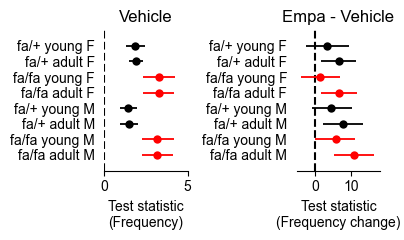

In [11]:
f, axes = plt.subplots(1, 2, figsize=(4, 2.5))
axes[1] = forestplot_oz(axes[1], ts_change);
axes[1].set_title("Empa - Vehicle");

axes[0] = forestplot_oz(axes[0], ts_vehicle);
axes[0].set_title("Vehicle");

for ax in axes:
    ax.spines[['top', 'right', 'left']].set_visible(False)
axes[1].set_xlabel('Test statistic\n(Frequency change)')
axes[0].set_xlabel('Test statistic\n(Frequency)')

axes[0].set_xlim(0, 5)
axes[1].set_xlim(-5,18)

f.tight_layout()
# f.savefig(PLOT_DIR / "ts_UrineFlow_groups.pdf", bbox_inches="tight")

## Compute and plot TS representing the difference between fa/fa and fa/+ genotypes

In [12]:
ts_change, ts_vehicle = (
    {
        "M adult":   t_groups["fa/fa:male:adult"] - t_groups["fa/+:male:adult"],
        "M young":   t_groups["fa/fa:male:young"] - t_groups["fa/+:male:young"],
        # "M": (t_groups["fa/fa:male:adult"] - t_groups["fa/+:male:adult"] + t_groups["fa/fa:male:young"] - t_groups["fa/+:male:young"])/2,
        "F adult": t_groups["fa/fa:female:adult"] - t_groups["fa/+:female:adult"],
        "F young": t_groups["fa/fa:female:young"] - t_groups["fa/+:female:young"],    
        # "F": (t_groups["fa/fa:female:adult"] - t_groups["fa/+:female:adult"] + t_groups["fa/fa:female:young"] - t_groups["fa/+:female:young"])/2
        # "adult": (t_groups["fa/fa:female:adult"] - t_groups["fa/+:female:adult"] + t_groups["fa/fa:male:adult"] - t_groups["fa/+:male:adult"])/2,
        # "young": (t_groups["fa/fa:female:young"] - t_groups["fa/+:female:young"] + t_groups["fa/fa:male:young"] - t_groups["fa/+:male:young"])/2
       
    }
    for t_groups in (t_groups_change, t_groups_bsl)
)

sign_probabilities_gtyp = pd.DataFrame({
    'change':get_sign_probs(ts_change),
    'change_signif':{k:get_signif(v) for k,v in get_sign_probs(ts_change).items()},
    'vehicle':get_sign_probs(ts_vehicle),
    'vehicle_signif':{k:get_signif(v) for k,v in get_sign_probs(ts_vehicle).items()},
})

print("Change sign probabilities:")
display(get_sign_probs(ts_change))
print("\nVehicle sign probabilities:")
display(get_sign_probs(ts_vehicle))

Change sign probabilities:


{'M adult': 0.79875, 'M young': 0.62475, 'F adult': 0.509, 'F young': 0.3135}


Vehicle sign probabilities:


{'M adult': 0.999, 'M young': 0.99875, 'F adult': 0.9935, 'F young': 0.99125}

[]

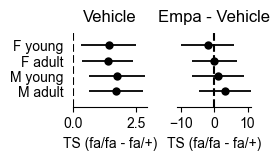

In [13]:
f, axes = plt.subplots(1, 2, figsize=(2.3, 1))
plt.subplots_adjust(wspace=0.4)

for ax, ts_, tle in zip(axes, (ts_vehicle, ts_change), ('Vehicle', 'Empa - Vehicle')):
    ax = forestplot_oz(ax, ts_);
    ax.set_title(tle);
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.set_xlabel('TS (fa/fa - fa/+)')


axes[0].set_xlim(0,None)
# axes[1].set_xlim(-1.1,2.2)
# axes[1].set_xticks([-0.01, 0], [-0.01, 0])
# axes[0].set_xticks([-0.01, 0, 0.01], [-0.01, 0, 0.01])


axes[1].set_yticks([],[])
# plt.tight_layout()
# f.savefig(PLOT_DIR / "ts_UrineFlow_CompareGtypForAgesSexes.pdf", bbox_inches="tight")

## Compute and plot TS representing the difference between young and adult

In [14]:
ts_change, ts_vehicle = (
    {
        "fa/fa":   t_groups["fa/fa:male:young"] - t_groups["fa/fa:male:adult"],
        "fa/+":   t_groups["fa/+:male:young"] - t_groups["fa/+:male:adult"],
        # "F fa/fa":  t_groups["fa/fa:female:young"] - t_groups["fa/fa:female:adult"],
        # "F fa/+":   t_groups["fa/+:female:young"] - t_groups["fa/+:female:adult"],
        # "fa/fa": (t_groups["fa/fa:female:young"] - t_groups["fa/fa:female:adult"] + t_groups["fa/fa:male:young"] - t_groups["fa/fa:male:adult"])/2,
        # "fa/+": (t_groups["fa/+:female:young"] - t_groups["fa/+:female:adult"] + t_groups["fa/+:male:young"] - t_groups["fa/+:male:adult"])/2,
        # "overall": (t_groups["fa/fa:young"]+t_groups["fa/fa:old"])/2 - (t_groups["fa/+:young"]+t_groups["fa/+:old"])/2,
        
    }
    for t_groups in (t_groups_change, t_groups_bsl)
)

sign_probabilities_age = pd.DataFrame({
    'change':get_sign_probs(ts_change),
    'change_signif':{k:get_signif(v) for k,v in get_sign_probs(ts_change).items()},
    'vehicle':get_sign_probs(ts_vehicle),
    'vehicle_signif':{k:get_signif(v) for k,v in get_sign_probs(ts_vehicle).items()},
})

print("Empa sign probabilities:")
display(get_sign_probs(ts_change))
print("\nVehicle sign probabilities:")
display(get_sign_probs(ts_vehicle))

Empa sign probabilities:


{'fa/fa': 0.05675, 'fa/+': 0.166}


Vehicle sign probabilities:


{'fa/fa': 0.50425, 'fa/+': 0.44575}

[]

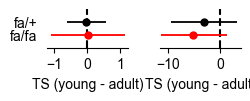

In [16]:
f, axes = plt.subplots(1, 2, figsize=(2.5, 0.5))
plt.subplots_adjust(wspace=0.4)

for ax, ts_, tle in zip(axes, (ts_vehicle, ts_change), ('Vehicle', 'Empagliflozin')):
    ax = forestplot_oz(ax, ts_);
    # ax.set_title(tle);
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.set_xlabel('TS (young - adult)')
    
# axes[0].set_xlim(-1.6,1.9)
axes[1].set_xlim(None, 4)

# axes[1].set_xticks([-0.005, 0, 0.005], [-0.005, 0, 0.005])
# axes[0].set_xticks([-0.01, 0, 0.01], [-0.01, 0, 0.01])

axes[1].set_yticks([],[])
# plt.tight_layout()
# f.savefig(PLOT_DIR / "ts_UrineFlow_CompareAgeForGtypsSexes.pdf", bbox_inches="tight")

## Compute and plot TS representing the difference between males and females

In [17]:
ts_change, ts_vehicle = (
    {
        "fa/fa":  t_groups["fa/fa:male:adult"] - t_groups["fa/fa:female:adult"],
        # "young fa/fa":   t_groups["fa/fa:male:young"] - t_groups["fa/fa:female:young"],
        "fa/+":   t_groups["fa/+:male:adult"] - t_groups["fa/+:female:adult"],
        # "young fa/+":   t_groups["fa/+:male:young"] - t_groups["fa/+:female:young"],
        # "adult": (t_groups["fa/fa:male:adult"] - t_groups["fa/+:male:adult"] + t_groups["fa/fa:female:adult"] - t_groups["fa/+:female:adult"])/2,
        # "young": (t_groups["fa/fa:male:young"] - t_groups["fa/+:male:young"] + t_groups["fa/fa:female:young"] - t_groups["fa/+:female:young"])/2,
        # "overall": (t_groups["fa/fa:young"]+t_groups["fa/fa:old"])/2 - (t_groups["fa/+:young"]+t_groups["fa/+:old"])/2,
        
    }
    for t_groups in (t_groups_change, t_groups_bsl)
)

sign_probabilities_sex = pd.DataFrame({
    'change':get_sign_probs(ts_change),
    'change_signif':{k:get_signif(v) for k,v in get_sign_probs(ts_change).items()},
    'vehicle':get_sign_probs(ts_vehicle),
    'vehicle_signif':{k:get_signif(v) for k,v in get_sign_probs(ts_vehicle).items()},
})

print("Empa sign probabilities:")
display(get_sign_probs(ts_change))
print("\nVehicle sign probabilities:")
display(get_sign_probs(ts_vehicle))

Empa sign probabilities:


{'fa/fa': 0.9175, 'fa/+': 0.63875}


Vehicle sign probabilities:


{'fa/fa': 0.4265, 'fa/+': 0.07675}

[]

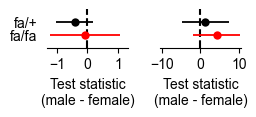

In [19]:
f, axes = plt.subplots(1, 2, figsize=(2.5, 0.5))
plt.subplots_adjust(wspace=0.4)

for ax, ts_, tle in zip(axes, (ts_vehicle, ts_change), ('Vehicle', 'Empagliflozin')):
    ax = forestplot_oz(ax, ts_);
    # ax.set_title(tle);
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.set_xlabel('Test statistic\n(male - female)')
    
# axes[0].set_xlim(-2.8,.7)
# axes[1].set_xlim(-.6, 1.8)
# axes[0].set_xticks([-0.005, 0, 0.005], [-0.005, 0, 0.005])
# axes[1].set_xticks([-0.01, 0], [-0.01, 0])
axes[1].set_yticks([],[])

# f.savefig(PLOT_DIR / "ts_UrineFlow_CompareSexesForGtypAges.pdf", bbox_inches="tight")

## Show sign probabilities in tables

In [20]:
sp_all = pd.concat(objs=(sign_probabilities_change,
                sign_probabilities_gtyp,
                sign_probabilities_age, 
                sign_probabilities_sex), 
                   keys=('urineFlow',
                         'fa/fa - fa/+',
                         'young - adult', 
                         'male - female'), 
                   names=('contrast', 
                          'group'))
# sp_all.to_csv('../sp_tables/UrineFlow.csv')
sp_all

change change_signif  vehicle vehicle_signif
contrast      group                                                       
urineFlow     fa/fa adult M  0.99975             *      NaN            NaN
              fa/fa young M  0.97475                    NaN            NaN
              fa/+ adult M   0.99550             *      NaN            NaN
              fa/+ young M   0.94675                    NaN            NaN
              fa/fa adult F  0.99375             *      NaN            NaN
              fa/fa young F  0.70525                    NaN            NaN
              fa/+ adult F   0.99350             *      NaN            NaN
              fa/+ young F   0.88275                    NaN            NaN
fa/fa - fa/+  M adult        0.79875                0.99900              *
              M young        0.62475                0.99875              *
              F adult        0.50900                0.99350              *
              F young        0.31350                0.99125              *
young - adult fa/fa          0.05675                0.50425               
              fa/+           0.16600                0.44575               
male - female fa/fa          0.91750                0.42650               
              fa/+           0.63875                0.07675